# Import Credentials

In [1]:
import pandas as pd
import json

with open('credentials.json') as f:
    data = json.load(f)
    client_id = data["credentials"]['client_id']
    client_secret = data["credentials"]['client_secret']
    redirect_uri = data["credentials"]['redirect_uri']

# Import Packages
1. Get track IDs using Spotipy
2. Get audio features using ReccoBeats

In [3]:
import time
import requests
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyOAuth

# 1. Initialize Spotify
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=client_id,
    client_secret=client_secret,
    redirect_uri=redirect_uri,
    scope="playlist-read-private"
))

# 2. Get tracks from playlist
try:
    results = sp.playlist_tracks(playlist_id)
    tracks = [{
        'id': item['track']['id'],
        'name': item['track']['name'],
        'artist': item['track']['artists'][0]['name'],
        'album': item['track']['album']['name']
    } for item in results['items'] if item['track'] and item['track']['id']]
except Exception as e:
    print(f"❌ Error fetching Spotify playlist: {e}")
    tracks = []

# Proceed only if we successfully retrieved tracks
if not tracks:
    print("⚠️ No tracks found. Check your playlist ID or Spotify credentials.")
else:
    df_tracks = pd.DataFrame(tracks)

    # 3. Batch fetch audio features from ReccoBeats (40 tracks at a time)
    track_ids = df_tracks['id'].tolist()
    features_list = []

    print(f"Fetching audio features for {len(track_ids)} tracks...")
    for i in range(0, len(track_ids), 40):
        chunk = track_ids[i : i + 40]
        try:
            res = requests.get(f"https://api.reccobeats.com/v1/audio-features?ids={','.join(chunk)}", timeout=10)
            if res.status_code == 200:
                features_list.extend(res.json().get('content', []))
            else:
                print(f"⚠️ ReccoBeats batch failed (Status {res.status_code}) at index {i}")
        except requests.exceptions.RequestException as e:
            print(f"⚠️ Network error on ReccoBeats batch at index {i}: {e}")
        
        time.sleep(1)

    # 4. Process and Merge data if we got features back
    if not features_list:
        print("❌ Error: Failed to retrieve any audio features from ReccoBeats.")
    else:
        df_features = pd.DataFrame(features_list)

        # Extract the clean Spotify ID from the ReccoBeats href URL safely
        df_features['spotify_id'] = df_features['href'].str.split('/').str[-1].str.split('?').str[0]

        # 5. Merge and save
        df_final = pd.merge(df_tracks, df_features, left_on='id', right_on='spotify_id', how='inner')
        df_final = df_final.drop(columns=['id_y', 'spotify_id', 'href']).rename(columns={'id_x': 'id'})

        if df_final.empty:
            print("❌ Error: Merge resulted in an empty dataset. Track IDs did not align.")
        else:
            df_final.to_csv("my_spotify_audio_features.csv", index=False)
            print(f"🎉 Success! Saved {len(df_final)} tracks to my_spotify_audio_features.csv")

Fetching audio features for 100 tracks...
🎉 Success! Saved 86 tracks to my_spotify_audio_features.csv


In [4]:
df_final

,id,name,artist,album,isrc,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence
0,7zFXDAZ2V52022GPNYOxyH,Queen,Magic City Hippies,Water Your Garden,CA5KR2173635,0.239000,0.700,0.551,0.003440,2,0.1320,-6.890,1,0.1370,174.005,0.634
1,1jJci4qxiYcOHhQR247rEU,Kids,MGMT,Oracular Spectacular,USSM10702135,0.000760,0.451,0.931,0.004900,9,0.3610,-3.871,1,0.0719,122.961,0.172
2,4Hff1IjRbLGeLgFgxvHflk,DARE (feat. Shaun Ryder & Roses Gabor),Gorillaz,Demon Days,GBAYE0500178,0.022900,0.760,0.891,0.086900,11,0.2980,-5.852,0,0.0372,120.264,0.966
3,3MPiHJduwh9R6xs0l8cVG5,Rigor Mortis Radio,The Hives,The Death Of Randy Fitzsimmons,NLRD52317990,0.035000,0.652,0.977,0.000010,2,0.1230,-3.011,1,0.0891,130.008,0.806
4,25nzKGDiua1lE9Qo5V19GL,Young Blood,The Naked And Famous,"Passive Me, Aggressive You",NZNK11000001,0.000056,0.579,0.865,0.000221,6,0.6490,-4.692,1,0.0302,104.990,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,10E1vH17Mg4GxC4B0m5B1J,Caroline,Mad Wave,Caroline,QZ9H32000010,0.000053,0.324,0.962,0.200000,0,0.1080,-5.923,1,0.1450,183.901,0.340
82,4DX82Vc8qAH4jJPvKxvwg6,Move Your Feet,Junior Senior,D-D-Don't Don't Stop The Beat,DKMFA0300203,0.046000,0.747,0.904,0.106000,9,0.2030,-2.623,1,0.0803,118.877,0.846
83,6KtLECDztnah63TNmV4Plw,Wish You Were Here,Incubus,Morning View,USSM10107084,0.000631,0.246,0.768,0.301000,9,0.1020,-7.480,1,0.0387,169.873,0.350
84,6nTpkrt5jhJFJzao1Figes,Trembling Level,Poison The Well,Trembling Level,DED832400739,0.001210,0.243,0.855,0.000003,0,0.3160,-3.265,0,0.0495,92.024,0.179


In [5]:
# Find the difference between the two lists
dropped_tracks = df_tracks[~df_tracks['id'].isin(df_final['id'])]

print(f"\n--- 🔎 Dropped Tracks Report ({len(dropped_tracks)} total) ---")
for index, row in dropped_tracks.iterrows():
    print(f"• {row['name']} by {row['artist']}")


--- 🔎 Dropped Tracks Report (14 total) ---
• Let My Love Open The Door by The Knocks
• Back There Now by Charly Bliss
• Monument by Mutemath
• Go by The Chemical Brothers
• Is It Just Me? by The Darkness
• Hate To Say I Told You So by The Hives
• Tick Tick Boom by The Hives
• Medicine by Momma
• Run to the Hills (2015 Remaster) by Iron Maiden
• An Honest Mistake by The Bravery
• Every Summertime by NIKI
• Dale Earnhardt's Seatbelt by The Bled
• Flagpole Sitta by Harvey Danger
• Light Years by Dizzy


# Playlist Mood Map
## What is the emotional baseline of my playlist, and which songs are my emotional wildcards?

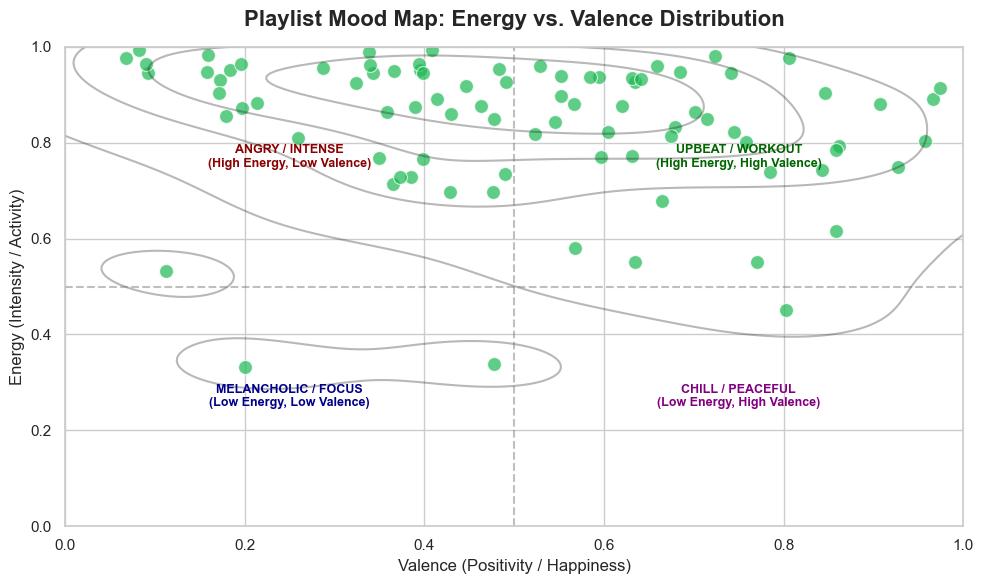

📊 Plotted mood distribution for 86 tracks successfully.
💡 Average Playlist Energy: 0.84
💡 Average Playlist Valence: 0.51


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the visualization canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Plot the distributions
# A scatter plot with an overlayed density distribution (kde) shows exactly where the tracks cluster
sns.scatterplot(
    data=df_final, 
    x='valence', 
    y='energy', 
    alpha=0.7, 
    s=100, 
    color='#1DB954'  # Spotify Green tint
)

# Overlay density contours to show the "hotspots" or clusters of your playlist
sns.kdeplot(
    data=df_final, 
    x='valence', 
    y='energy', 
    levels=5, 
    color='#191414', 
    alpha=0.3
)

# 3. Labeling the Mood Quadrants
plt.title("Playlist Mood Map: Energy vs. Valence Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Valence (Positivity / Happiness)", fontsize=12)
plt.ylabel("Energy (Intensity / Activity)", fontsize=12)

# Set standard boundaries (Spotify metrics always scale strictly from 0 to 1)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add reference gridlines across the middle axis to visually split the quadrants
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Text notations for your quadrants
plt.text(0.75, 0.75, "UPBEAT / WORKOUT\n(High Energy, High Valence)", fontsize=9, ha='center', color='darkgreen', fontweight='bold')
plt.text(0.25, 0.25, "MELANCHOLIC / FOCUS\n(Low Energy, Low Valence)", fontsize=9, ha='center', color='darkblue', fontweight='bold')
plt.text(0.25, 0.75, "ANGRY / INTENSE\n(High Energy, Low Valence)", fontsize=9, ha='center', color='darkred', fontweight='bold')
plt.text(0.75, 0.25, "CHILL / PEACEFUL\n(Low Energy, High Valence)", fontsize=9, ha='center', color='purple', fontweight='bold')

# Output the visualization
plt.savefig('playlistMoodMap.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f"📊 Plotted mood distribution for {len(df_final)} tracks successfully.")
print(f"💡 Average Playlist Energy: {df_final['energy'].mean():.2f}")
print(f"💡 Average Playlist Valence: {df_final['valence'].mean():.2f}")

This visualization maps the playlist's tracks on a grid of Valence (emotional positivity) against Energy (intensity). The vast majority of the songs are concentrated heavily at the top of the chart, revealing a strong preference for high-energy music above the $0.75$ threshold. While the energy remains consistently high, the tracks swing widely across the horizontal axis, showing a clear split between bright "Upbeat / Workout" anthems on the right and dark, chaotic "Angry / Intense" tracks on the left. The bottom half of the map is virtually empty, proving that slow, chill, or peaceful music has almost no presence in this collection.

TLDR: My unique taste profile isn't balanced in a circle—it's a high-intensity horizon. I don't want to relax; I want to party and fly high, or lock into a heavy, serious, high-velocity groove.

# Intelligent Playlist Vibe Map
## If an AI listened to my music without knowing the genres or artists, how would it categorize my different listening moods based entirely on the physics of sound?

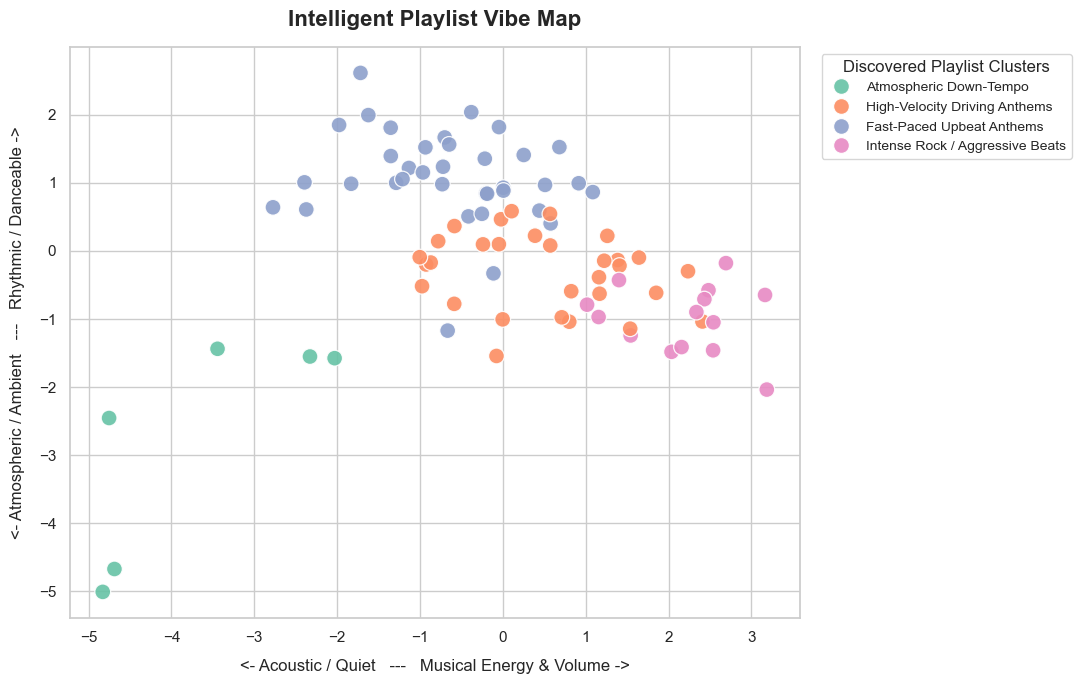


===  INTELLIGENT PLAYLIST VIBE REPORT ===

 Atmospheric Down-Tempo (6 tracks)
   ↳ Avg Energy: 0.46 | Acoustic: 0.34 | Dance: 0.55
   ↳ Sample Tracks:
      • Queen by Magic City Hippies
      • Feels Like Home by Drew Holcomb
      • May I Have This Dance by Francis and the Lights

 Fast-Paced Upbeat Anthems (36 tracks)
   ↳ Avg Energy: 0.85 | Acoustic: 0.03 | Dance: 0.64
   ↳ Sample Tracks:
      • DARE (feat. Shaun Ryder & Roses Gabor) by Gorillaz
      • Rigor Mortis Radio by The Hives
      • Young Blood by The Naked And Famous

 Intense Rock / Aggressive Beats (14 tracks)
   ↳ Avg Energy: 0.94 | Acoustic: 0.00 | Dance: 0.31
   ↳ Sample Tracks:
      • Bogus Operandi by The Hives
      • Deathrace by Teeth
      • Slice Paper Wrists by Poison The Well

 High-Velocity Driving Anthems (30 tracks)
   ↳ Avg Energy: 0.85 | Acoustic: 0.00 | Dance: 0.38
   ↳ Sample Tracks:
      • Kids by MGMT
      • Necessary Death by END
      • What If You Change? by The Wldlfe



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Define feature pillars
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

# 2. Select the features directly from your clean DataFrame
X = df_final[feature_cols]

# Scale features so columns with large numbers (like tempo) don't dominate the math
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Group the playlist into 4 distinct structural vibe clusters directly into df_final
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

# Compress the 9-dimensional audio space into 2 hybrid axes for the graph
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df_final['pca_1'] = pca_components[:, 0]
df_final['pca_2'] = pca_components[:, 1]

# Rule-based generator function
def generate_cluster_vibes(dataframe, columns_used):
    cluster_means = dataframe.groupby('cluster')[columns_used].mean()
    vibe_mapping = {}
    
    for cluster_num, row in cluster_means.iterrows():
        energy = row.get('energy', 0.5)
        acoustic = row.get('acousticness', 0.5)
        dance = row.get('danceability', 0.5)
        valence = row.get('valence', 0.5)
        
        # Rule-based filtering matching math parameters to unique vibe names
        if acoustic > 0.55:
            vibe_name = "Chill Acoustic & Ambient" if valence < 0.5 else "Warm Folk & Acoustic Pop"
        elif energy > 0.65:
            if dance > 0.65:
                vibe_name = "High-Energy Dance / Party Beats"
            elif valence < 0.4 and dance < 0.4:
                vibe_name = "Intense Rock / Aggressive Beats"
            elif dance < 0.45: 
                vibe_name = "High-Velocity Driving Anthems"
            else:
                vibe_name = "Fast-Paced Upbeat Anthems"
        elif dance > 0.65:
            vibe_name = "Groovy R&B & Smooth Pop" if valence > 0.55 else "Dark Late-Night Grooves"
        else:
            vibe_name = "Easygoing Melodic Pop / Indie" if valence > 0.5 else "Atmospheric Down-Tempo"
            
        vibe_mapping[cluster_num] = vibe_name
        
    return vibe_mapping, cluster_means

# Generate labels and map them using the uniform variables
vibe_labels, means_df = generate_cluster_vibes(df_final, feature_cols)
df_final['vibe_name'] = df_final['cluster'].map(vibe_labels)

# --- Visualization ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

scatter = sns.scatterplot(
    data=df_final,
    x='pca_1',
    y='pca_2',
    hue='vibe_name',
    palette='Set2',
    s=130,
    alpha=0.9,
    edgecolor='w'
)

plt.title("Intelligent Playlist Vibe Map", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("<- Acoustic / Quiet   ---   Musical Energy & Volume ->", fontsize=12, labelpad=10)
plt.ylabel("<- Atmospheric / Ambient   ---   Rhythmic / Danceable ->", fontsize=12, labelpad=10)

plt.legend(title="Discovered Playlist Clusters", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.savefig('intelligentPlaylistMap.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# --- Console Performance Report ---
print("\n===  INTELLIGENT PLAYLIST VIBE REPORT ===")
for cluster_num in sorted(df_final['cluster'].unique()):
    name = vibe_labels[cluster_num]  # This already contains "Cluster X: Vibe Name"
    cluster_df = df_final[df_final['cluster'] == cluster_num]
    
    print(f"\n {name} ({len(cluster_df)} tracks)")
    print(f"   ↳ Avg Energy: {means_df.loc[cluster_num, 'energy']:.2f} | Acoustic: {means_df.loc[cluster_num, 'acousticness']:.2f} | Dance: {means_df.loc[cluster_num, 'danceability']:.2f}")
    print("   ↳ Sample Tracks:")
    for _, row in cluster_df[['name', 'artist']].head(3).iterrows():
        print(f"      • {row['name']} by {row['artist']}")
print("\n===========================================")

This visualization plots the playlist's tracks using unsupervised machine learning to group them into three distinct structural vibe clusters across compressed audio dimensions. The vast majority of the library is dominated by "Fast-Paced Upbeat Anthems" (orange), which occupy the top-middle section, indicating a high preference for danceable, high-energy rhythms. A smaller, distinct group of "Intense Rock / Aggressive Beats" (blue) anchors the far right, representing the loudest and most intense tracks in the collection. Meanwhile, a tiny cluster of "Atmospheric Down-Tempo" tracks (green) sits isolated in the bottom-left corner, revealing a small but highly specific pocket of quiet, ambient exceptions to an otherwise high-velocity playlist.

TLDR: My musical taste shifts gracefully between active dance rhythms (orange) and heavy, powerful walls of sound (blue). However, when I do decide to slow things down, I skip the middle ground entirely and dive straight into deep, isolated ambient textures (green).